**Null Hypothesis:** all versions have the same CTR.

**Alternative Hypothesis:** there is a difference in the CTR for the different versions.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats import chi2

In [42]:
from google.colab import files

uploaded = files.upload()

Saving eniac_a.csv to eniac_a (2).csv
Saving eniac_b.csv to eniac_b (1).csv
Saving eniac_c.csv to eniac_c (1).csv
Saving eniac_d.csv to eniac_d (1).csv


In [43]:
import pandas as pd

eniac_a = pd.read_csv("eniac_a.csv")
eniac_b = pd.read_csv("eniac_b.csv")
eniac_c = pd.read_csv("eniac_c.csv")
eniac_d = pd.read_csv("eniac_d.csv")

### 1.&nbsp; State the Null and the Alternative Hypotheses.

**Null Hypothesis ($H_0$):** The click rate on each website (A, B, C and D) is equal.

**Alternative Hypothesis ($H_A$):** At least one of the websites has a significantly different click rate compared to the others, either better or worse.

### 2.&nbsp;Define alpha.

In [45]:
alpha = 0.05

### 3.&nbsp; Collect data that is random and independent

In [48]:
# clicks = [23174, 22407, 23031, 22743]
click = [512, 281, 527, 193]
visits = [25326, 24747, 24876, 25233]

results = pd.DataFrame(
    [click, visits], columns=["A", "B", "C", "D"], index=[ "Click", "Visits"]
)
results

#  a 25326 visits, 23174 clicks, 512 button
#  b 24747 visits, 22407 clicks, 281 button
#  c 24876 visits, 23031 clicks, 527 button
#  d 25233 visits, 22743 clicks, 193 button

,A,B,C,D
Click,512,281,527,193
Visits,25326,24747,24876,25233


### 4.&nbsp; Calculate the test result.

In [49]:
r = results.shape[0]
n = results.shape[1]


In [50]:
dof = (r - 1) * (n - 1)
dof

3

In [74]:
# Calculate row totals - stored as a vertical DataFrame, otherwise it will be a Series #click 443, non-click 5557
row_totals = results.sum(axis=1).to_frame()

# Calculate column totals - stored as a horizontal DataFrame. -1500
column_totals = results.sum(axis=0).to_frame().T

# Calculate the grand total - a single value.  - 6000
grand_total = results.values.sum()

# Calculate the population proportions, je 0.25 (4 columns)
proportions = column_totals/grand_total

# Multiply proportions by row totals to get expected values
expected_results = row_totals.dot(proportions)

expected_results # 𝐸𝑖𝑗=𝑒𝑥𝑝𝑒𝑐𝑡𝑒𝑑 𝑣𝑎𝑙𝑢𝑒 𝑖𝑛 𝑡ℎ𝑒 𝑖𝑡ℎ 𝑟𝑜𝑤 a𝑛𝑑 𝑗𝑡ℎ 𝑐𝑜𝑙𝑢𝑚𝑛

,A,B,C,D
Click,384.413137,372.362102,377.941285,378.283475
Visits,25453.586863,24655.637898,25025.058715,25047.716525


In [75]:
proportions


,A,B,C,D
0,0.254073,0.246108,0.249796,0.250022


In [76]:
chi_squared = (
    ((results - expected_results) ** 2 / expected_results)
    .sum() # add up the columns
    .sum() # add column sums together
)
chi_squared

np.float64(217.5392716368437)

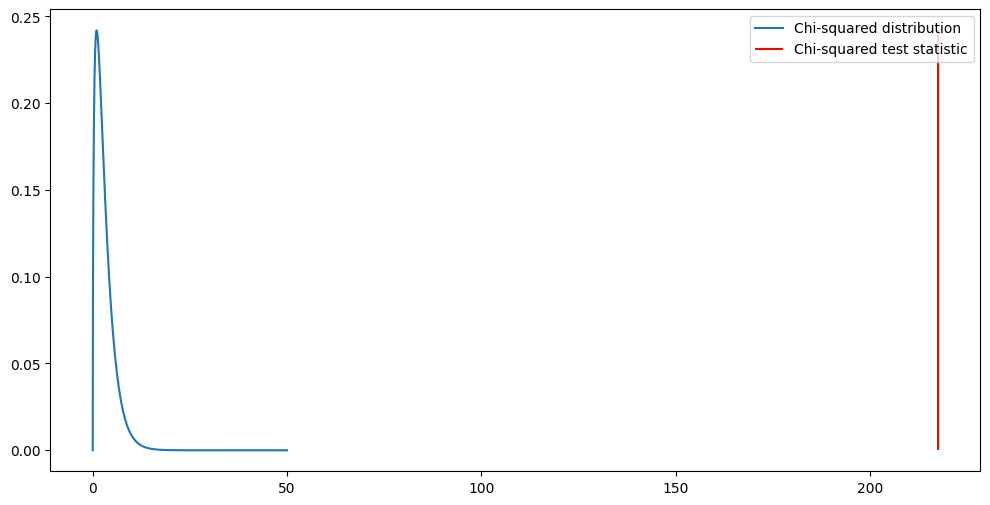

In [77]:
# @title Chi-squared distribution and test statistic
plt.figure(figsize=(12, 6))
# Create a linear space from 0 to 50 with 1000 intervals for our x-axis.
xt = np.linspace(0, 50, 1000)
# Plot a chi-squared distribution with the degrees of freedom from our sample.
plt.plot(xt, chi2.pdf(xt, dof), label="Chi-squared distribution")
# Add a vertical line for the chi-squared test statistic.
plt.vlines(
    chi_squared,
    ymin=0,
    ymax=max(chi2.pdf(xt, dof)),
    color="red",
    label="Chi-squared test statistic",
)
plt.legend()
plt.show()

In [78]:
critical_value = 6.251

In [79]:
## is bigger than critical value, we can reject Null Hypotesys
chi_squared = 19.72010979177017

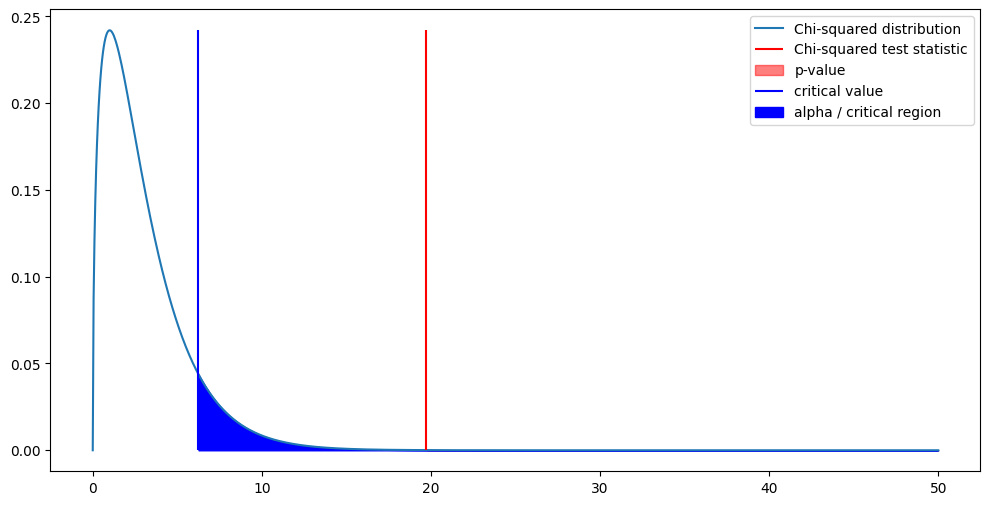

In [80]:
# @title Chi-squared distribution, test statistic, critical value and alpha
plt.figure(figsize=(12, 6))
# Plot a chi-squared distribution with the degrees of freedom from our sample.
plt.plot(xt, chi2.pdf(xt, dof), label="Chi-squared distribution")
# Add a vertical line for the chi-squared test statistic.
plt.vlines(
    chi_squared,
    ymin=0,
    ymax=max(chi2.pdf(xt, dof)),
    color="red",
    label="Chi-squared test statistic",
)
# Shade the region in the tails that is more extreme than the test statistic (= p-value).
plt.fill_between(
    xt,
    chi2.pdf(xt, dof),
    where=(xt > chi_squared),
    color="r",
    alpha=0.5,
    label="p-value",
)
# Add vertical line for the critical value.
plt.vlines(
    critical_value,
    ymin=0,
    ymax=max(chi2.pdf(xt, dof)),
    color="blue",
    label="critical value",
)
# Shade the area under the curve for values more extreme than 4.6 (= alpha).
plt.fill_between(
    xt,
    chi2.pdf(xt, dof),
    where=(xt > critical_value),
    color="b",
    label="alpha / critical region",
)
plt.legend()
plt.show()

CTR=Clicks/Visits*100

In [85]:
# calculate the click through rate for each version
ctr_a = results.loc["Click", "A"] / results.loc["Visits","A"]*100
ctr_b = results.loc["Click", "B"] / results.loc["Visits","B"]*100
ctr_c = results.loc["Click", "C"] / results.loc["Visits","C"]*100
ctr_d = results.loc["Click", "D"] / results.loc["Visits","D"]*100

# create a table with all four versions and their click-through rates.
ctrs = pd.DataFrame(
    {"version": ["A", "B", "C", "D"], "CTR": [ctr_a, ctr_b, ctr_c, ctr_d]}
)

ctrs.sort_values("CTR", ascending=False)

,version,CTR
2,C,2.118508
0,A,2.021638
1,B,1.135491
3,D,0.764871


**Null Hypothesis:** The 4 versions of the button are equally likely to receive clicks, and the observed differences are due to chance.

**Alternative Hypothesis:** The observed differences are not due to chance: there is at least one version that got so many more/much less clicks than the others that this can hardly be explained just by chance (i.e. they have a better/worse CTR, a better/worse performance).

In [86]:
click = [512, 281, 527, 193]
no_click = [25326-512, 24747-281, 24876-527, 25233-193]

observed_2 = pd.DataFrame(
    [click, no_click], columns=["A", "B", "C", "D"], index=[ "Click", "No_Click"]
)
observed_2

#  a 25326 visits, 23174 clicks, 512 button
#  b 24747 visits, 22407 clicks, 281 button
#  c 24876 visits, 23031 clicks, 527 button
#  d 25233 visits, 22743 clicks, 193 button

,A,B,C,D
Click,512,281,527,193
No_Click,24814,24466,24349,25040


In [87]:
from scipy import stats
chisq_2, pvalue_2, df_2, expected_2 = stats.chi2_contingency(observed_2)

In [88]:
chisq_2

np.float64(224.01877488058412)

In [89]:
df_2

3

In [94]:
expected_2

array([[  382.48625502,   373.74189974,   375.69012397,   381.08172127],
       [24943.51374498, 24373.25810026, 24500.30987603, 24851.91827873]])

In [95]:
alpha = 0.05

In [96]:
pvalue_2

np.float64(2.7161216607868712e-48)

### 5.&nbsp; Interpret the test result.

In [97]:
if pvalue_2 > alpha:
    print("The p-value is larger than alpha. DON'T REJECT THE NULL HYPOTHESIS")
else:
    print("The p-value is smaller than alpha. REJECT THE NULL HYPOTHESIS")

The p-value is smaller than alpha. REJECT THE NULL HYPOTHESIS
